# Equivariant Projection Networks - a visual tutorial

## One ordinary MLP + every symmetry-related view + an average

\[
\boxed{\mathcal P_G[f](x)=\frac{1}{|G|}\sum_{g\in G}D_Y(g)^{-1}f(D_X(g)x)}
\]

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

ROOT = Path.cwd()
if not (ROOT / 'epn').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from epn import *
from epn.correlation import collapse_coordinates

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
torch.manual_seed(7)
COLORS = ['#2563eb','#dc2626','#059669','#d97706','#7c3aed','#0891b2','#db2777','#4b5563']

## 1. The eight views of a square-lattice environment

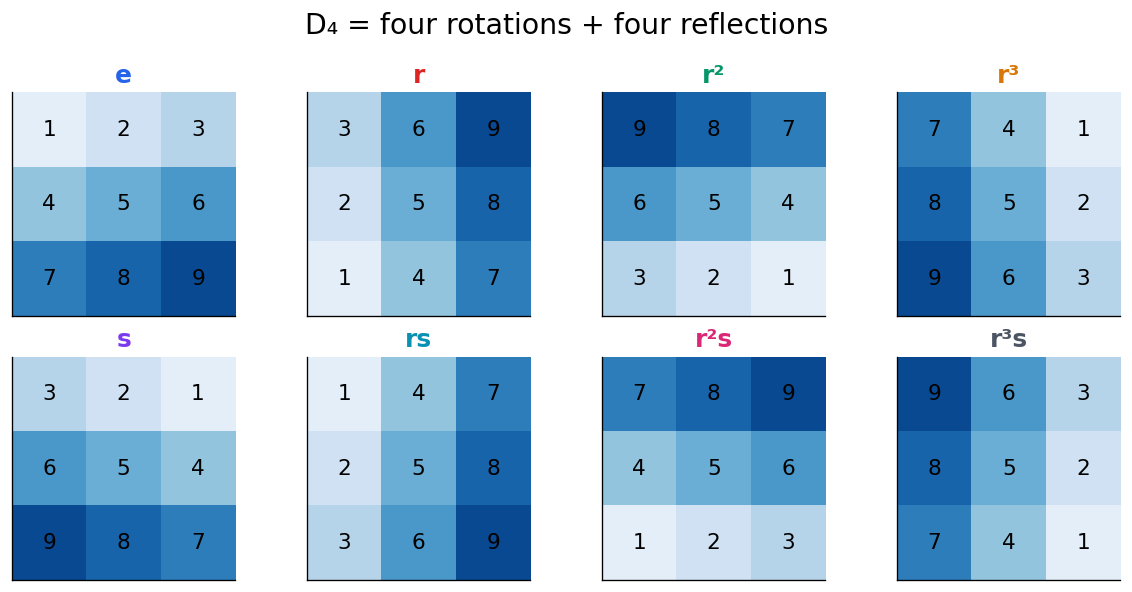

In [2]:
patch = np.arange(1, 10).reshape(3, 3)
views = [np.rot90(patch, k) for k in range(4)]
views += [np.rot90(np.fliplr(patch), k) for k in range(4)]
names = ['e', 'r', 'r²', 'r³', 's', 'rs', 'r²s', 'r³s']
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, view, name, color in zip(axes.flat, views, names, COLORS):
    ax.imshow(view, cmap='Blues', vmin=0, vmax=10)
    for (y,x), value in np.ndenumerate(view):
        ax.text(x, y, value, ha='center', va='center', fontsize=13)
    ax.set_title(name, color=color, fontsize=15, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('D₄ = four rotations + four reflections', fontsize=17)
fig.tight_layout()

## 2. The projection is a small wrapper around any neural network

(0.0, 1.0)

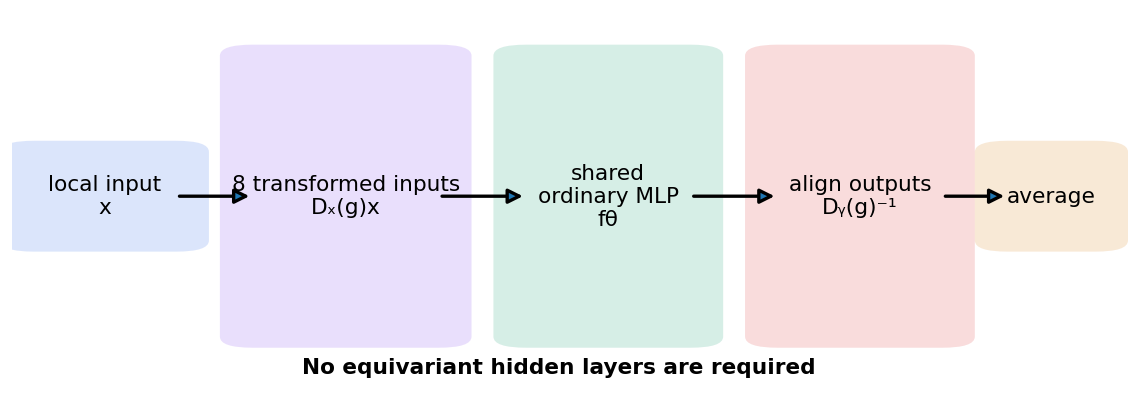

In [3]:
fig, ax = plt.subplots(figsize=(12, 4)); ax.axis('off')
def box(x, y, w, h, text, color):
    p = FancyBboxPatch((x,y),w,h,boxstyle='round,pad=.03',fc=color,ec='none',alpha=.16)
    ax.add_patch(p); ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=13)
box(.02,.38,.13,.24,'local input\nx',COLORS[0])
box(.22,.12,.17,.76,'8 transformed inputs\nDₓ(g)x',COLORS[4])
box(.47,.12,.15,.76,'shared\nordinary MLP\nfθ',COLORS[2])
box(.70,.12,.15,.76,'align outputs\nDᵧ(g)⁻¹',COLORS[1])
box(.91,.38,.08,.24,'average',COLORS[3])
for a,b in [(.15,.22),(.39,.47),(.62,.70),(.85,.91)]:
    ax.add_patch(FancyArrowPatch((a,.5),(b,.5),arrowstyle='-|>',mutation_scale=18,lw=2))
ax.text(.5,.02,'No equivariant hidden layers are required',ha='center',fontsize=13,fontweight='bold')
ax.set_xlim(0,1.02); ax.set_ylim(0,1)

## 3. Scalar output: averaging creates exact invariance

maximum invariance error: 1.3877787807814457e-17


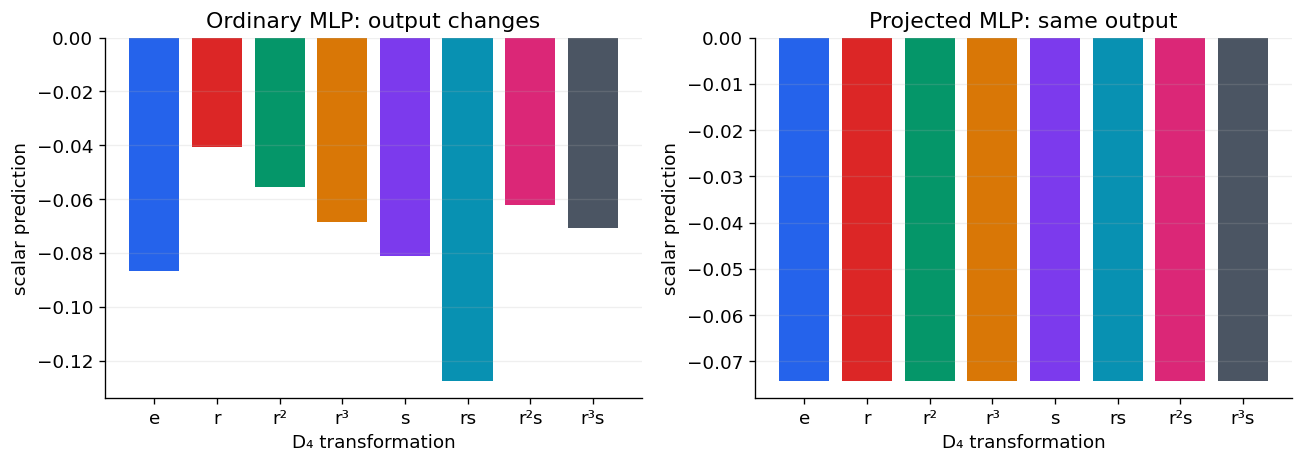

In [4]:
coordinates = square_offsets(5)
scalar_model = InvariantEnergyModel(coordinates, hidden_dims=(32,16)).double()
x = torch.randn(1,25,dtype=torch.double)
perms = input_permutations(coordinates)
raw = np.array([scalar_model.backbone(x[:,p]).item() for p in perms])
projected = np.array([scalar_model(x[:,p]).item() for p in perms])
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].bar(names,raw,color=COLORS); axes[0].set_title('Ordinary MLP: output changes')
axes[1].bar(names,projected,color=COLORS); axes[1].set_title('Projected MLP: same output')
for ax in axes: ax.set_xlabel('D₄ transformation'); ax.set_ylabel('scalar prediction'); ax.grid(axis='y',alpha=.2)
fig.tight_layout()
print('maximum invariance error:', max(abs(projected-projected[0])))

## 4. Directional output: rotate the input, rotate the answer

maximum equivariance error: 1.3877787807814457e-17


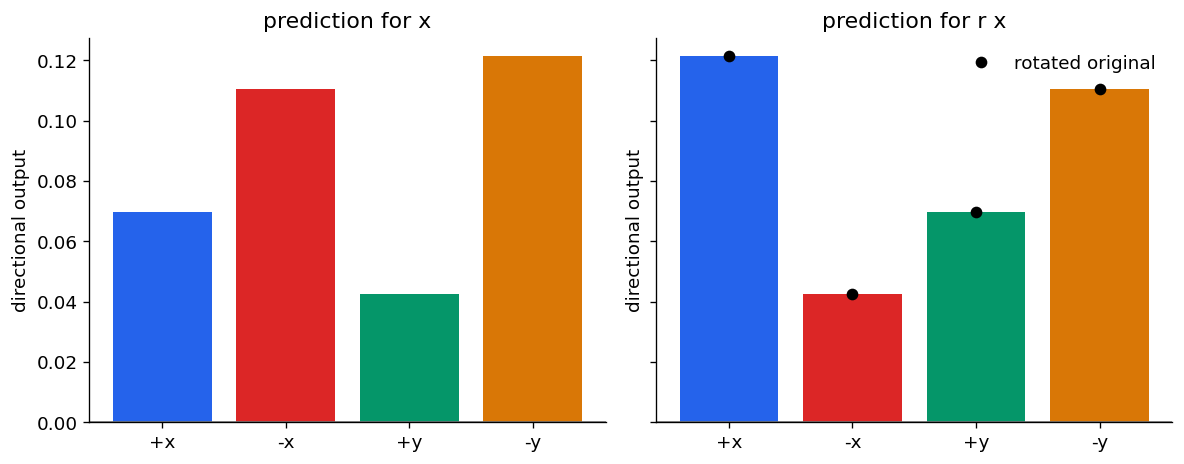

In [5]:
coordinates_fk_small = circular_offsets(3)
vector_model = DirectionalEPN(coordinates_fk_small,hidden_dims=(32,16)).double()
x = torch.randn(1,len(coordinates_fk_small),dtype=torch.double)
y = vector_model(x)[0].detach().numpy()
inp = input_permutations(coordinates_fk_small)[1]
out = output_permutations(DIRECTION_VECTORS)[1]
y_rotated_input = vector_model(x[:,inp])[0].detach().numpy()
y_rotated_answer = y[out]
fig, axes = plt.subplots(1,2,figsize=(10,4),sharey=True)
labels=['+x','-x','+y','-y']
axes[0].bar(labels,y,color=COLORS[:4]); axes[0].set_title('prediction for x')
axes[1].bar(labels,y_rotated_input,color=COLORS[:4]); axes[1].plot(labels,y_rotated_answer,'ko',label='rotated original')
axes[1].set_title('prediction for r x'); axes[1].legend(frameon=False)
for ax in axes: ax.axhline(0,color='.5',lw=1); ax.set_ylabel('directional output')
fig.tight_layout()
print('maximum equivariance error:', abs(y_rotated_input-y_rotated_answer).max())

## 5. Falicov-Kimball EPN: 317 occupations in, four hopping energies out

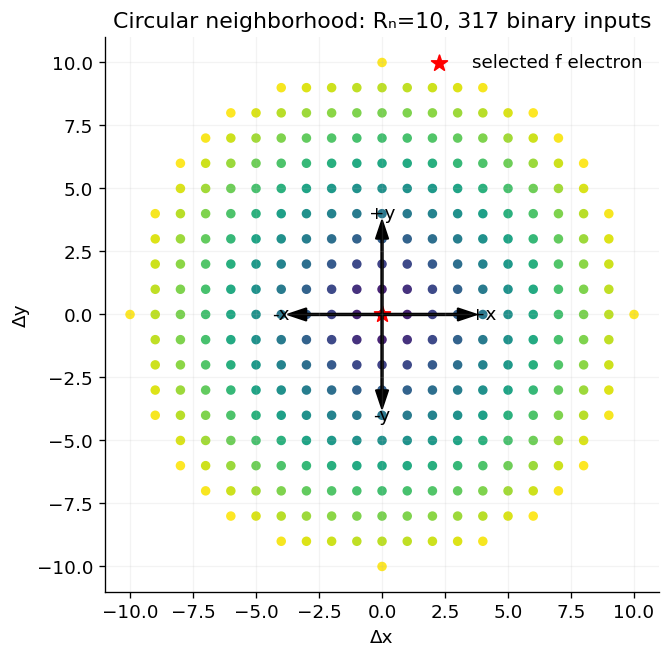

In [6]:
offsets = circular_offsets(10)
fig, ax = plt.subplots(figsize=(6,6))
xy=np.array(offsets); ax.scatter(xy[:,0],xy[:,1],s=22,c=np.hypot(xy[:,0],xy[:,1]),cmap='viridis')
ax.scatter([0],[0],s=100,c='red',marker='*',label='selected f electron')
for dx,dy,label in [(1,0,'+x'),(-1,0,'-x'),(0,1,'+y'),(0,-1,'-y')]:
    ax.arrow(0,0,dx*3,dy*3,width=.07,head_width=.5,color='black'); ax.text(dx*4,dy*4,label,ha='center',va='center')
ax.set(aspect='equal',xlabel='Δx',ylabel='Δy',title=f'Circular neighborhood: Rₙ=10, {len(offsets)} binary inputs')
ax.legend(frameon=False); ax.grid(alpha=.15)

Text(0.5, 1.0, 'FK backbone evaluated on all eight D₄ views')

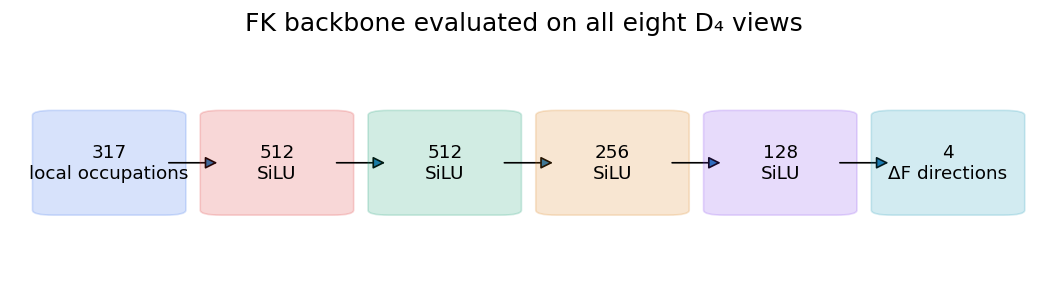

In [7]:
fig, ax = plt.subplots(figsize=(11,2.7)); ax.axis('off')
layers=[('317','local occupations'),('512','SiLU'),('512','SiLU'),('256','SiLU'),('128','SiLU'),('4','ΔF directions')]
xs=np.linspace(.04,.86,len(layers))
for i,((width,label),x0) in enumerate(zip(layers,xs)):
    boxw=.11; p=FancyBboxPatch((x0,.32),boxw,.38,boxstyle='round,pad=.02',fc=COLORS[i%len(COLORS)],alpha=.18,ec=COLORS[i%len(COLORS)])
    ax.add_patch(p); ax.text(x0+boxw/2,.51,width+'\n'+label,ha='center',va='center')
    if i<len(layers)-1: ax.add_patch(FancyArrowPatch((x0+boxw,.51),(xs[i+1],.51),arrowstyle='-|>',mutation_scale=15))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_title('FK backbone evaluated on all eight D₄ views',fontsize=15)

## 6. Holstein IPN: local energy → total energy → conservative force

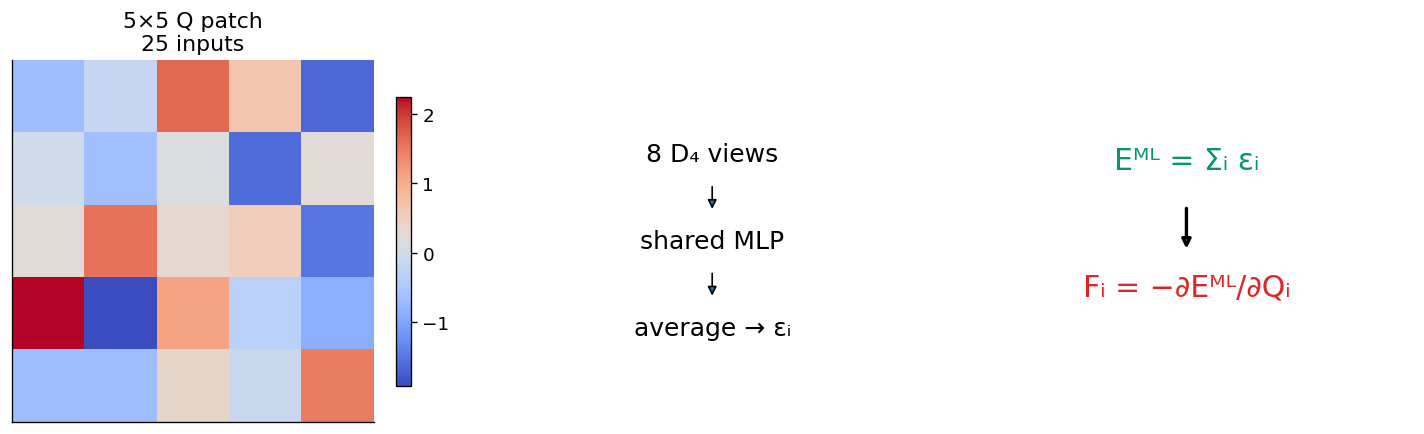

In [8]:
rng=np.random.default_rng(4); qpatch=rng.normal(size=(5,5))
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
im=axes[0].imshow(qpatch,cmap='coolwarm'); axes[0].set_title('5×5 Q patch\n25 inputs'); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].axis('off'); axes[1].text(.5,.72,'8 D₄ views',ha='center',fontsize=15); axes[1].text(.5,.48,'shared MLP',ha='center',fontsize=15); axes[1].text(.5,.24,'average → εᵢ',ha='center',fontsize=15)
axes[1].annotate('',(.5,.58),(.5,.66),arrowprops={'arrowstyle':'-|>'}); axes[1].annotate('',(.5,.34),(.5,.42),arrowprops={'arrowstyle':'-|>'})
axes[2].axis('off'); axes[2].text(.5,.7,'Eᴹᴸ = Σᵢ εᵢ',ha='center',fontsize=18,color=COLORS[2]); axes[2].text(.5,.35,'Fᵢ = −∂Eᴹᴸ/∂Qᵢ',ha='center',fontsize=18,color=COLORS[1]); axes[2].annotate('',(.5,.47),(.5,.6),arrowprops={'arrowstyle':'-|>','lw':2})
fig.colorbar(im,ax=axes[0],shrink=.8); fig.tight_layout()

Text(0.5, 1.0, 'Holstein local-energy backbone')

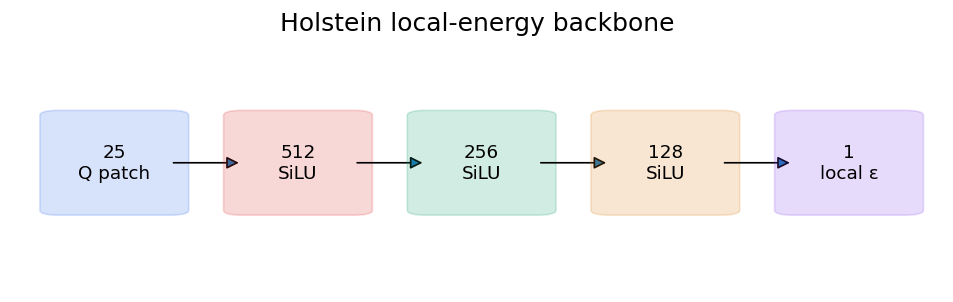

In [9]:
fig, ax = plt.subplots(figsize=(10,2.7)); ax.axis('off')
layers=[('25','Q patch'),('512','SiLU'),('256','SiLU'),('128','SiLU'),('1','local ε')]
xs=np.linspace(.05,.84,len(layers))
for i,((width,label),x0) in enumerate(zip(layers,xs)):
    p=FancyBboxPatch((x0,.32),.12,.38,boxstyle='round,pad=.02',fc=COLORS[i],alpha=.18,ec=COLORS[i]); ax.add_patch(p)
    ax.text(x0+.06,.51,width+'\n'+label,ha='center',va='center')
    if i<len(layers)-1: ax.add_patch(FancyArrowPatch((x0+.12,.51),(xs[i+1],.51),arrowstyle='-|>',mutation_scale=15))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_title('Holstein local-energy backbone',fontsize=15)

## 7. These are real ED-derived training labels

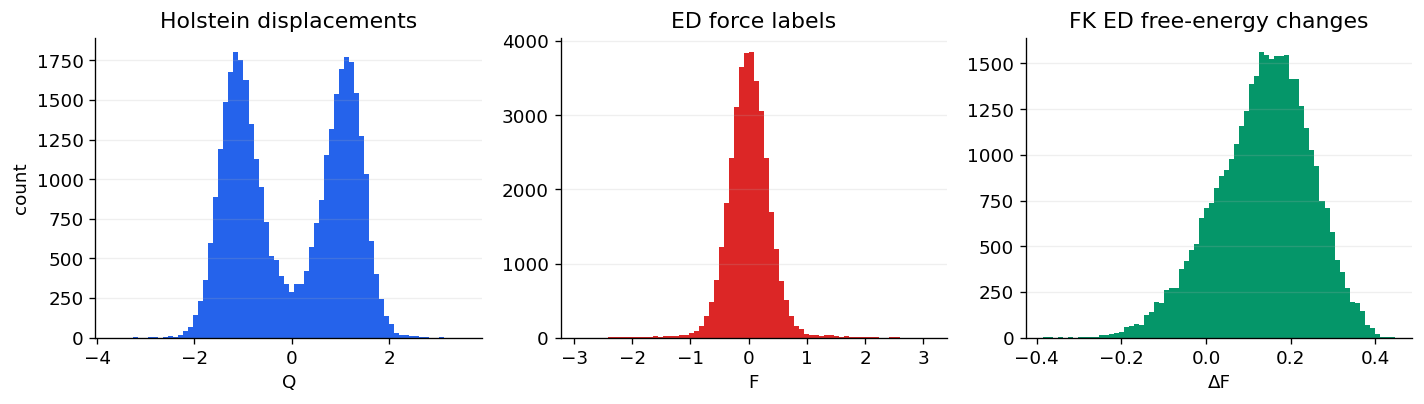

In [10]:
h=np.load(ROOT/'data/sample/holstein_real_sample.npz')
fk=pd.read_csv(ROOT/'data/sample/fk_real_sample.csv.gz')
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
axes[0].hist(h['Q'].ravel(),bins=70,color=COLORS[0]); axes[0].set(title='Holstein displacements',xlabel='Q',ylabel='count')
axes[1].hist(h['force'].ravel(),bins=70,color=COLORS[1]); axes[1].set(title='ED force labels',xlabel='F')
targets=fk[['deltaF_px','deltaF_mx','deltaF_py','deltaF_my']].to_numpy(); masks=fk[['mask_px','mask_mx','mask_py','mask_my']].to_numpy(bool)
axes[2].hist(targets[masks],bins=70,color=COLORS[2]); axes[2].set(title='FK ED free-energy changes',xlabel='ΔF')
for ax in axes: ax.grid(axis='y',alpha=.2)
fig.tight_layout()

## 8. Real validation: ED and ML must agree dynamically

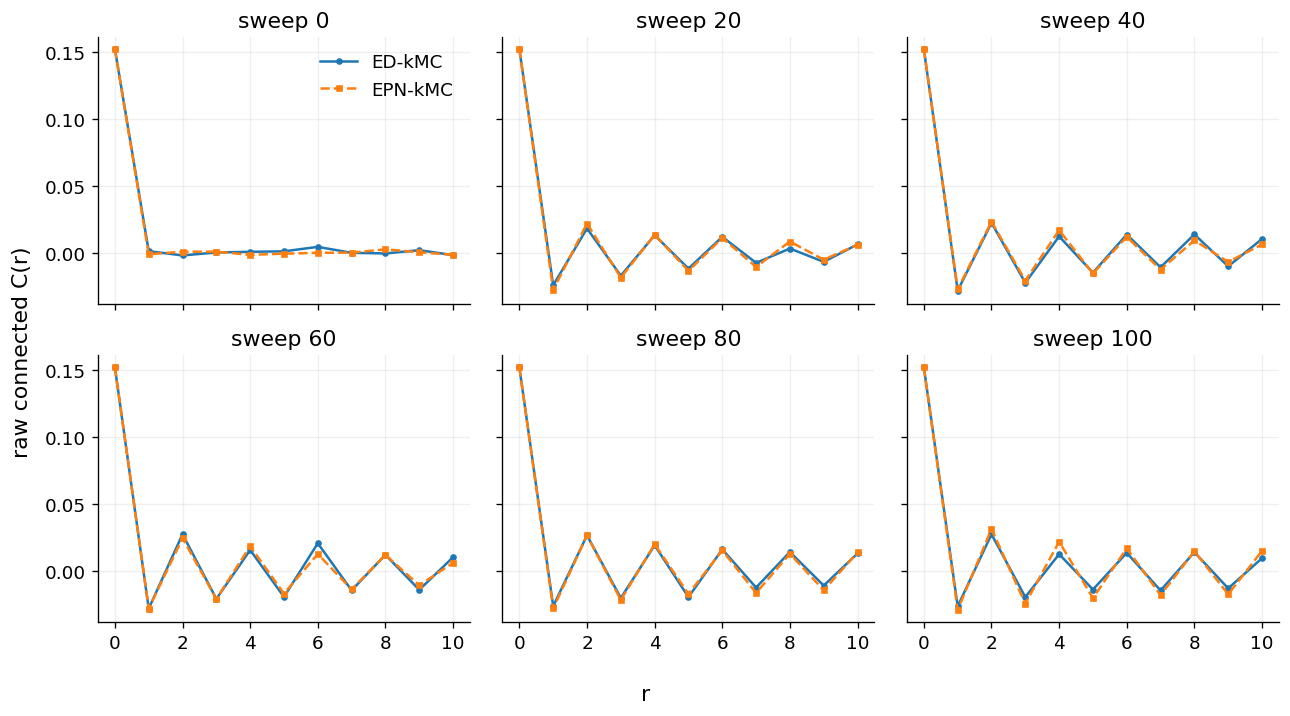

In [11]:
benchmark_root=ROOT/'data/full/manuscript_benchmarks'
if not benchmark_root.exists():
    print('Run: python scripts/download_data.py manuscript_benchmarks.zip --extract')
else:
    fk_corr=pd.read_csv(benchmark_root/'fk/correlation_comparison_epoch0300.csv')
    fig,axes=plt.subplots(2,3,figsize=(11,6),sharex=True,sharey=True)
    for ax,sweep in zip(axes.flat,[0,20,40,60,80,100]):
        d=fk_corr[fk_corr.sweep==sweep]
        ax.plot(d.radius,d.ED_C,'o-',ms=3,label='ED-kMC'); ax.plot(d.radius,d.ML_C,'s--',ms=3,label='EPN-kMC')
        ax.set_title(f'sweep {sweep}'); ax.grid(alpha=.2)
    axes.flat[0].legend(frameon=False); fig.supxlabel('r'); fig.supylabel('raw connected C(r)'); fig.tight_layout()

## 9. Coarsening collapse: many times, one curve

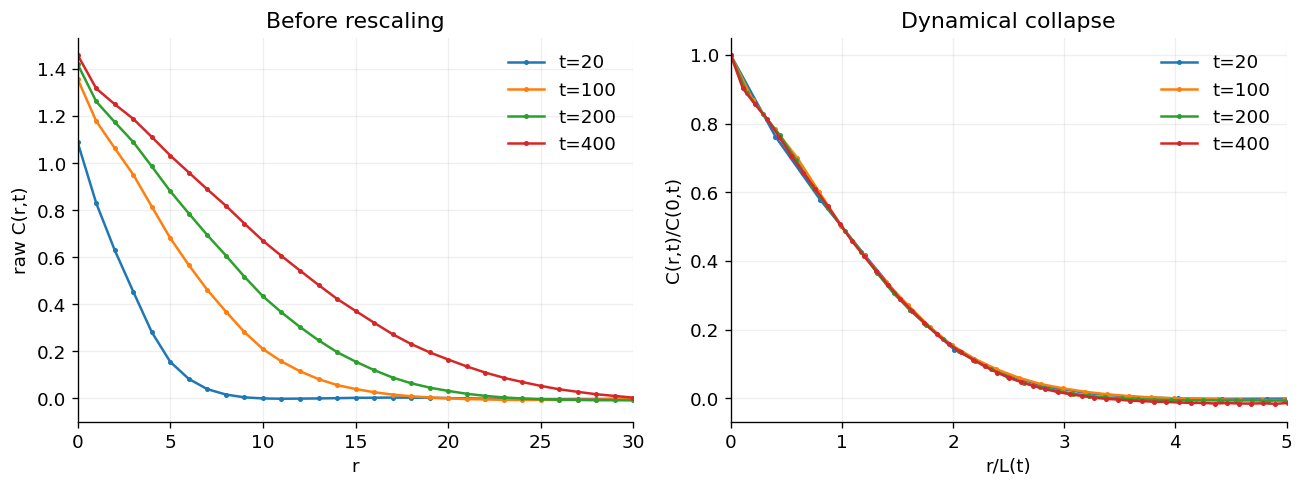

In [12]:
if benchmark_root.exists():
    d=np.loadtxt(benchmark_root/'holstein/collapse_long.txt')
    fig,axes=plt.subplots(1,2,figsize=(11,4.2))
    for time in np.unique(d[:,0]):
        rows=d[d[:,0]==time]
        axes[0].plot(rows[:,2],rows[:,4],marker='o',ms=2,label=f't={time:g}')
        axes[1].plot(rows[:,3],rows[:,6],marker='o',ms=2,label=f't={time:g}')
    axes[0].set(xlabel='r',ylabel='raw C(r,t)',title='Before rescaling',xlim=(0,30))
    axes[1].set(xlabel='r/L(t)',ylabel='C(r,t)/C(0,t)',title='Dynamical collapse',xlim=(0,5))
    for ax in axes: ax.grid(alpha=.2); ax.legend(frameon=False)
    fig.tight_layout()

# The complete recipe

\[
\text{microscopic configuration}
\xrightarrow{\;D_4\text{ projection}\;}
\text{exact symmetry}
\xrightarrow{\;\text{training}\;}
\text{ED accuracy}
\xrightarrow{\;\text{dynamics}\;}
\text{collective ordering}
\]